C:\Users\user\AppData\Local\Temp\ipykernel_38988\305122752.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Spawn_Strategy', y='Used_Tick', palette='Blues')


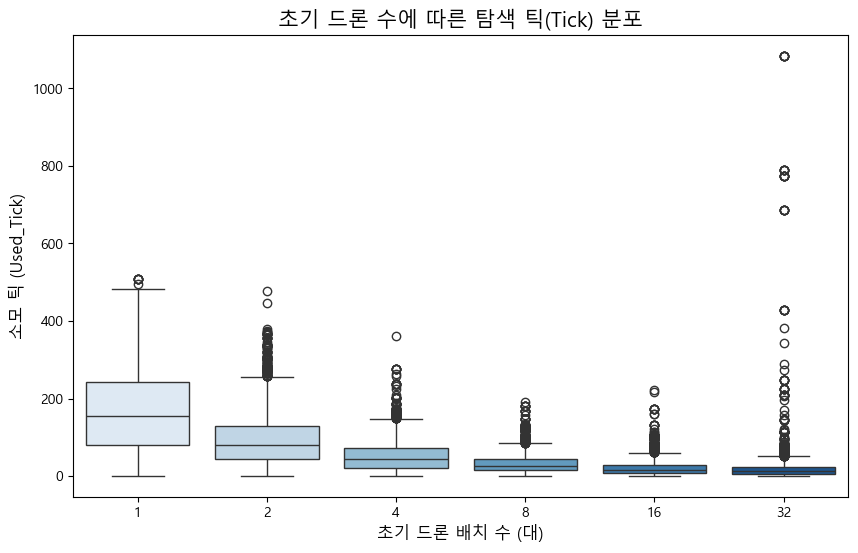

[1단계 ANOVA 검정] P-value: 0.00000

결론: 초기 드론 배치 수에 따라 탐색 성능에 유의미한 차이가 존재합니다.

[2단계 Tukey HSD 사후 검정 표]
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
     1      2  -71.4003    0.0  -75.4097  -67.3908   True
     1      4 -114.8828    0.0 -118.8923 -110.8734   True
     1      8  -134.674    0.0 -138.6834 -130.6645   True
     1     16  -145.213    0.0 -149.2224 -141.2035   True
     1     32 -141.6267    0.0 -145.6361 -137.6173   True
     2      4  -43.4826    0.0   -47.492  -39.4732   True
     2      8  -63.2737    0.0  -67.2831  -59.2643   True
     2     16  -73.8127    0.0  -77.8221  -69.8033   True
     2     32  -70.2264    0.0  -74.2359   -66.217   True
     4      8  -19.7911    0.0  -23.8005  -15.7817   True
     4     16  -30.3301    0.0  -34.3395  -26.3207   True
     4     32  -26.7438    0.0  -30.7533  -22.7344   True
     8     16   -10.539    0.0

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. 데이터 불러오기 및 정렬 (Spawn_Strategy가 이미 숫자이므로 바로 사용 가능)
df = pd.read_csv('simulation_results.csv')
df = df.sort_values('Spawn_Strategy')

# 2. 박스 플롯 시각화 (눈으로 최적점과 틱이 튀어 오르는 구간 확인)
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'Malgun Gothic' # 맥은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

sns.boxplot(data=df, x='Spawn_Strategy', y='Used_Tick', palette='Blues')
plt.title('초기 드론 수에 따른 탐색 틱(Tick) 분포', fontsize=15)
plt.xlabel('초기 드론 배치 수 (대)', fontsize=12)
plt.ylabel('소모 틱 (Used_Tick)', fontsize=12)
plt.show()

# ---------------------------------------------------------
# 3. 분산 분석 (ANOVA) 및 사후 검정
# ---------------------------------------------------------
groups = [group['Used_Tick'].values for name, group in df.groupby('Spawn_Strategy')]
f_stat, p_value = stats.f_oneway(*groups)

print(f"[1단계 ANOVA 검정] P-value: {p_value:.5f}\n")

if p_value < 0.05:
    print("결론: 초기 드론 배치 수에 따라 탐색 성능에 유의미한 차이가 존재합니다.\n")
    print("="*50)
    print("[2단계 Tukey HSD 사후 검정 표]")
    print("="*50)
    
    # 튜키 검정 실행
    tukey_result = pairwise_tukeyhsd(endog=df['Used_Tick'], 
                                     groups=df['Spawn_Strategy'], 
                                     alpha=0.05)
    print(tukey_result)
else:
    print("결론: 통계적으로 유의미한 성능 차이가 발견되지 않았습니다.")

In [4]:
df['Waste_Tick']

0          1
5274       1
16578      1
16584      1
5268       1
        ... 
19979      1
14525     17
6809       5
14531    413
23609      9
Name: Waste_Tick, Length: 23610, dtype: int64